In [1]:
# Training
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from CNN import SymbolClassifierCNN

In [2]:
X_train = torch.from_numpy(np.load("Datasets/X_train.npy"))
Y_train = torch.from_numpy(np.load("Datasets/Y_train.npy"))
X_eval = torch.from_numpy(np.load("Datasets/X_eval.npy"))
Y_eval = torch.from_numpy(np.load("Datasets/Y_eval.npy"))

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

eval_dataset = TensorDataset(X_eval, Y_eval)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=True)

input_size = 150 * 135
num_classes = 16

model = SymbolClassifierCNN(num_classes=num_classes)

device = torch.device("cpu")
model = model.to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

Epoch 1/10, training loss: 1.5171
Epoch 2/10, training loss: 0.7008
Epoch 3/10, training loss: 0.4728
Epoch 4/10, training loss: 0.2882
Epoch 5/10, training loss: 0.1887
Epoch 6/10, training loss: 0.1380
Epoch 7/10, training loss: 0.1028
Epoch 8/10, training loss: 0.0684
Epoch 9/10, training loss: 0.0534
Epoch 10/10, training loss: 0.0402


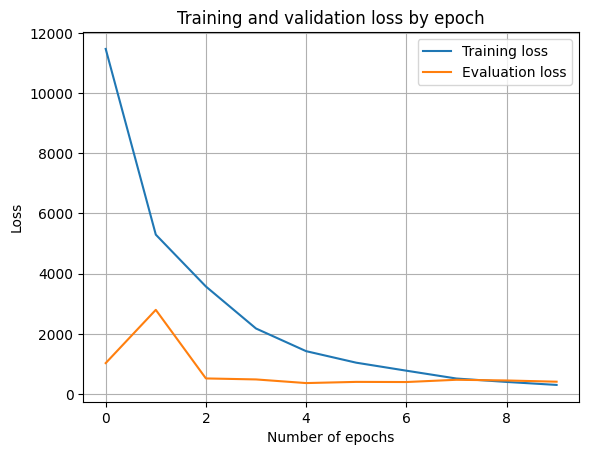

In [3]:
# Training loop

training_loss = []
evaluation_loss = []
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

    eval_loss = 0
    for inputs, labels in eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        eval_loss += loss.item() * inputs.size(0)
    
    epoch_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}, training loss: {epoch_loss:.4f}")
    training_loss.append(total_loss)
    evaluation_loss.append(eval_loss)

fig, ax1 = plt.subplots(1, 1)
ax1.plot(training_loss, label="Training loss")
ax1.plot(evaluation_loss, label="Evaluation loss")
ax1.set_xlabel("Number of epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Training and validation loss by epoch")
ax1.legend()
ax1.grid(True)

In [4]:
torch.save(model.state_dict(), "symbol_classifier.pth")